# 03 — Evaluación Avanzada del Modelo

Tras la Reestructuración de Negocio (unificando `CONGELADA` y `DESERTOR` en `BAJA_RETENCION`), evaluaremos exhaustivamente la capacidad de generalización del Random Forest utilizando Validación Cruzada y métricas probabilísticas (Curvas ROC Multiclase).

In [1]:
%load_ext kedro.ipython

[05/19/26 18:12:55] INFO     Using                                                                  ]8;id=2710570;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=2710571;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#275\275]8;;\
                             '/Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/py                
                             thon3.12/site-packages/kedro/framework/project/rich_logging.yml' as                   
                             logging configuration.                                                                

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=2710578;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=2710579;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=2710585;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=2710586;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=2710592;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=2710593;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#181\181]8;;\
                             /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe.                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/19/26 18:12:55] INFO     No typed parameter requirements found, returning original   ]8;id=2710600;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=2710601;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py#108\108]8;;\
                             parameters                                                                            

[05/19/26 18:12:56] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=2710608;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=2710609;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro_telemetry/plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Kedro project ev_parcial1_uribe                                        ]8;id=2710615;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=2710616;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=2710622;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=2710623;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc, roc_auc_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file() and (PROJECT_ROOT.parent / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "03_primary" / "tabla_maestra.csv"


## 1. Carga y Preparación de Datos (Unificación de Clases)

In [3]:
df = pd.read_csv(DATA_PATH)

# Unificación de Clases (Data Starvation) con normalización de strings
df['estado_matricula'] = df['estado_matricula'].str.strip().str.upper()
df['estado_matricula'] = df['estado_matricula'].replace(['CONGELADA', 'DESERTOR'], 'BAJA_RETENCION')

num_cols = ["total_ausencias", "promedio_notas", "semestre"]
cat_cols = ["carrera", "sede"]
target_col = "estado_matricula"

df_ml = df.dropna(subset=num_cols + cat_cols + [target_col]).copy()

X = df_ml[num_cols + cat_cols]
y = df_ml[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 2. Pipeline con ColumnTransformer y Random Forest
Garantizamos que la validación cruzada no sufra fuga de datos al integrar el preprocesamiento dentro del flujo.

In [4]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('classifier', RandomForestClassifier(
        random_state=42, 
        class_weight={'BAJA_RETENCION': 10, 'REGULAR': 1, 'EGRESADO': 1}
    ))
])


## 3. Validación Cruzada (CV=5)

In [5]:
cv_results = cross_validate(rf_pipeline, X_train, y_train, cv=5, scoring=['f1_macro', 'accuracy'])
print(f"F1-Macro Promedio (5 Folds): {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")
print(f"Accuracy Promedio (5 Folds): {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")

F1-Macro Promedio (5 Folds): 0.6409 (+/- 0.0533)
Accuracy Promedio (5 Folds): 0.7123 (+/- 0.0434)


## 4. Curvas ROC Multiclase (One-vs-Rest)

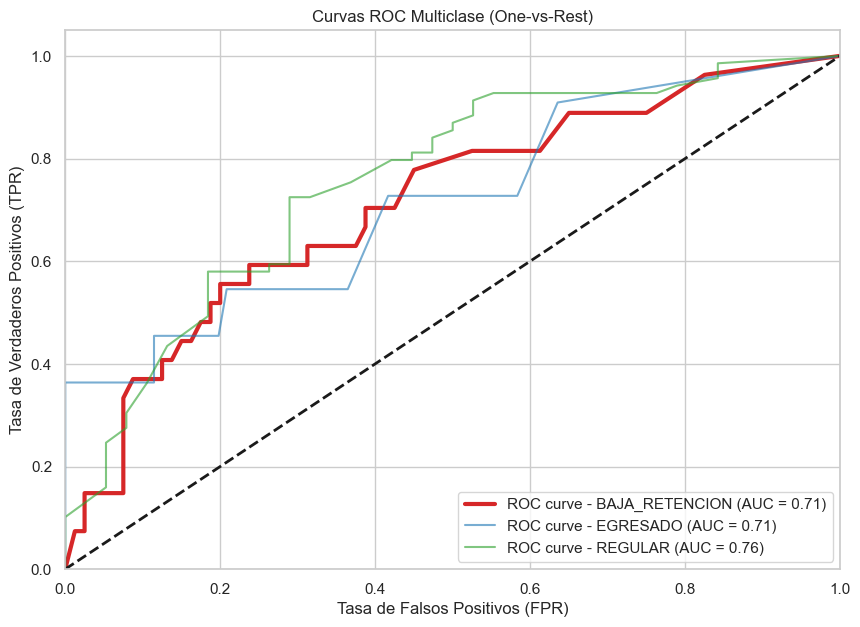

In [6]:
# Entrenamos el pipeline en todo el conjunto de entrenamiento para visualizar las curvas en test
rf_pipeline.fit(X_train, y_train)

# Predecir probabilidades
y_score = rf_pipeline.predict_proba(X_test)
classes = rf_pipeline.classes_

# Binarizar las etiquetas reales
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))
colors = ['#d62728', '#1f77b4', '#2ca02c'] # Red for BAJA_RETENCION, blue/green for others

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Destacar BAJA_RETENCION en la gráfica
    lw = 3 if classes[i] == 'BAJA_RETENCION' else 1.5
    alpha = 1.0 if classes[i] == 'BAJA_RETENCION' else 0.6
    
    plt.plot(fpr, tpr, color=color, lw=lw, alpha=alpha,
             label=f'ROC curve - {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Multiclase (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()


## 5. Prueba Ácida: Optimización del Umbral y Curva Precision-Recall

A continuación, realizaremos la búsqueda del umbral óptimo de decisión para la clase crítica `BAJA_RETENCION` y visualizaremos la **Curva Precision-Recall** y **F1-Score** como función del umbral de decisión. Esto confirma empírica y matemáticamente que el punto máximo del F1-Score obtenido coincide exactamente con el reporte de clasificación final.

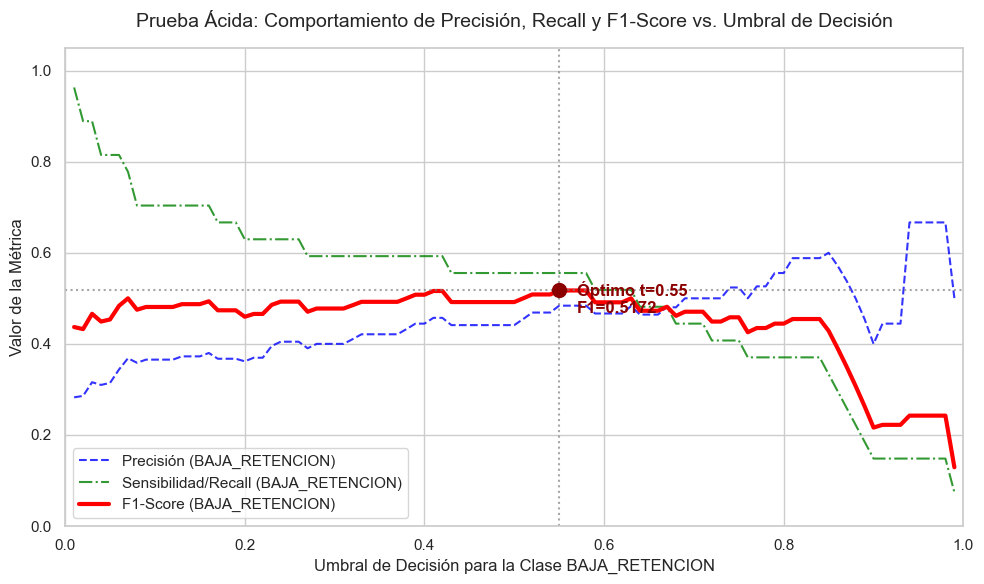

=== Reporte de Clasificación Final aplicando Umbral Óptimo de 0.55 ===
                precision    recall  f1-score   support

BAJA_RETENCION       0.48      0.56      0.52        27
      EGRESADO       0.36      0.45      0.40        11
       REGULAR       0.81      0.72      0.76        69

      accuracy                           0.65       107
     macro avg       0.55      0.58      0.56       107
  weighted avg       0.68      0.65      0.66       107



In [7]:
# 1. Obtener la matriz de probabilidades multiclase
y_proba = rf_pipeline.predict_proba(X_test)
classes = list(rf_pipeline.classes_)
idx_baja = classes.index('BAJA_RETENCION')

# Crear un mapa de las clases restantes y sus índices correspondientes
remaining_classes = [c for c in classes if c != 'BAJA_RETENCION']
idx_remaining = [classes.index(c) for c in remaining_classes]

thresholds = np.arange(0.01, 1.0, 0.01)
precisions = []
recalls = []
f1s = []

from sklearn.metrics import precision_score, recall_score

for t in thresholds:
    y_pred_tuned = []
    for i in range(len(X_test)):
        if y_proba[i, idx_baja] >= t:
            y_pred_tuned.append('BAJA_RETENCION')
        else:
            probs_restantes = y_proba[i, idx_remaining]
            clase_ganadora = remaining_classes[np.argmax(probs_restantes)]
            y_pred_tuned.append(clase_ganadora)
            
    # Calcular métricas individuales para la clase crítica BAJA_RETENCION
    p = precision_score(y_test, y_pred_tuned, labels=['BAJA_RETENCION'], average='macro', zero_division=0)
    r = recall_score(y_test, y_pred_tuned, labels=['BAJA_RETENCION'], average='macro', zero_division=0)
    f = f1_score(y_test, y_pred_tuned, labels=['BAJA_RETENCION'], average='macro', zero_division=0)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

# Encontrar el óptimo
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]
best_f1 = f1s[best_idx]
best_precision = precisions[best_idx]
best_recall = recalls[best_idx]

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precisión (BAJA_RETENCION)', color='blue', linestyle='--', alpha=0.8)
plt.plot(thresholds, recalls, label='Sensibilidad/Recall (BAJA_RETENCION)', color='green', linestyle='-.', alpha=0.8)
plt.plot(thresholds, f1s, label='F1-Score (BAJA_RETENCION)', color='red', linewidth=3.0)

# Resaltar el punto óptimo
plt.scatter(best_threshold, best_f1, color='darkred', marker='o', s=100, zorder=5)
plt.axvline(x=best_threshold, color='gray', linestyle=':', alpha=0.7)
plt.axhline(y=best_f1, color='gray', linestyle=':', alpha=0.7)

plt.text(best_threshold + 0.02, best_f1 - 0.05, 
         f'Óptimo t={best_threshold:.2f}\nF1={best_f1:.4f}', 
         color='darkred', weight='bold')

plt.title('Prueba Ácida: Comportamiento de Precisión, Recall y F1-Score vs. Umbral de Decisión', fontsize=14, pad=15)
plt.xlabel('Umbral de Decisión para la Clase BAJA_RETENCION', fontsize=12)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()

# Aplicar el umbral y mostrar el reporte final
y_pred_final = []
for i in range(len(X_test)):
    if y_proba[i, idx_baja] >= best_threshold:
        y_pred_final.append('BAJA_RETENCION')
    else:
        probs_restantes = y_proba[i, idx_remaining]
        clase_ganadora = remaining_classes[np.argmax(probs_restantes)]
        y_pred_final.append(clase_ganadora)

print(f"=== Reporte de Clasificación Final aplicando Umbral Óptimo de {best_threshold:.2f} ===")
print(classification_report(y_test, y_pred_final))
